In [5]:
import numpy as np
import pandas as pd
import xarray as xr
import cfgrib

import utils_plus_vishnu
import utils
from package_name.evaluation import plots as eval_plots
from package_name.evaluation.utils import predict_clusters
from package_name.evaluation import metrics
from package_name.training.trainer import VAETrainer, VAEConfig
from package_name.training.finetuner import VAEFinetuner
from package_name.tuning.cross_validator import CrossValidator
from package_name.inference.predictor import VAEPredictor
from package_name.model.utils import sampling, LossFactorsConfig
from package_name.evaluation.pca_kmeans import PCAKmeansTrainer,  PCAKmeansPredictor


import matplotlib.pyplot as plt
plt.style.use('default')



## Parameters and Config


In [6]:
g0 = 9.80665
extended_winter_months = [11, 12, 1, 2, 3]
results_path = "/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_results/training_test_split/"
data_path = "/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_data/wind/"
cluster_number = 4
original_dim = 575
pr_cluster_number = 4
batch_size = 128
epochs = 500

In [7]:
cluster_number = 4

config = VAEConfig(
    original_dim=original_dim,
    original_dim_target=pr_cluster_number,
    dim_layer1=256,
    dim_layer2=128,
    dim_layer3=64,
    activation="relu",
    cluster_number=cluster_number,
    latent_dim=10,
    pr_cluster_number=pr_cluster_number,
    sampling_fn=sampling,
)

## Data loading and pre-processing

In [8]:
# load the dataframes for clusters and normalized data
df_target_clusters = pd.read_csv(data_path + "WON_clusters_norm.csv", index_col=0)
df_target = pd.read_csv(data_path + "WON_country_wise_norm.csv", index_col=0)

In [9]:
# Get training data
z500 = utils.preprocess_dataset(filename = "/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_data/z500/era5_z500_daily_250_atlantic_1940_2022.nc",
                             variable_name = 'z',
                             multiplication_factor = 1/g0,
                             geographical_filter = 'extended europe',
                             months_filter = extended_winter_months,
                             anomalies = True,
                             normalization = False,
                             rolling_window = 5)

z500 = z500.where(z500['time.year'] > 1980, drop=True)
z500 = z500.where(z500['time.year'] < 2023, drop=True)


weights = np.cos(np.deg2rad(z500.latitude))
z500 = z500*weights
std_dev = z500.std()
z500 = z500/z500.std()

z500_reshaped = utils.reshape_data_for_clustering(z500)


# Get training data labels
pr_labels = pd.read_csv(data_path + 'WON_clusters_norm.csv')
pr_labels.columns = ['index', 'labels']
#pr_labels.drop(pr_labels.tail(1).index,inplace=True)

pr_labels['values']=[1]*len(pr_labels)
target_categorical_pd = pd.pivot_table(pr_labels, values='values', index=['index'],
                    columns=['labels'], aggfunc=np.sum).fillna(0)
target_categorical = target_categorical_pd.values



In [10]:
#set training and testing data
training_indices = np.where(z500['time.year'] < 2015)[0]
testing_indices = np.where(z500['time.year'] >= 2015)[0]

z500_training = z500[training_indices]
z500_testing = z500[testing_indices]

z500_reshaped_training = z500_reshaped[training_indices]
z500_reshaped_testing = z500_reshaped[testing_indices]

target_categorical_training = target_categorical[training_indices]
target_categorical_testing = target_categorical[testing_indices]

df_target_training = df_target.iloc[training_indices]
df_target_testing = df_target.iloc[testing_indices]

In [11]:
print("count of each label", target_categorical.sum(axis=0)/target_categorical.sum())

count of each label [0.23126574 0.38617758 0.16813602 0.21442065]


## Finetuning

In [12]:
#load all seasonal forecasts for 2004-2020 starting on JF, 1, 8, 15, 22
for month in [1, 2]:
    for day in [1, 8, 15, 22]:
        mem_ds = xr.open_dataset(
            "/net/helium/atmosdyn/vselvakumar/Data/C4E/Energy_var/s2s/plev_data_perturbed_members_2004" + str(month).zfill(2) + str(day).zfill(2) + "-2020" + str(month).zfill(2) + str(day).zfill(2) + ".grb",
            engine="cfgrib",
        )
        con_ds = xr.open_dataset(
            "/net/helium/atmosdyn/vselvakumar/Data/C4E/Energy_var/s2s/plev_data_unperturbed_control_member_2004" + str(month).zfill(2) + str(day).zfill(2) + "-2020" + str(month).zfill(2) + str(day).zfill(2) + ".grb",
            engine="cfgrib",
        )

        ds_all = xr.concat([mem_ds, con_ds], dim="number")

        ds_days_anom_temp = utils_plus_vishnu.preprocess_forecast_data(
                dataset=ds_all,
                variable_name="gh",
                multiplication_factor=1.0,
                geographical_filter=utils_plus_vishnu.GeographicalFilter.EXTENDED_EUROPE,
                anomalies=True,
                normalization=False,
                rolling_window=5,
                spatial_resolution=2.5,
                #weights=weights,
                ) 

        if month == 1 and day == 1:
            ds_days_anom = ds_days_anom_temp
        else:
            ds_days_anom = xr.concat([ds_days_anom, ds_days_anom_temp], dim="time")

In [15]:
time_pd = pd.to_datetime(ds_days_anom["time"].values)
delta_time_pd = pd.to_timedelta(ds_days_anom["days"], unit="D")

ds_days_anom = ds_days_anom.assign_coords(
    valid_time=(("time", "days"), np.empty((len(time_pd), len(delta_time_pd)), dtype="datetime64[ns]"))
)

for i in range(len(time_pd)):
    for j in range(len(delta_time_pd)):
        ds_days_anom["valid_time"][i, j] = time_pd[i] + delta_time_pd[j]

In [16]:
z500_hind_all_members = ds_days_anom.isel(days=14).gh 
z500_hind_all_members = z500_hind_all_members * weights
z500_hind_all_members = z500_hind_all_members/std_dev

In [17]:
valid_times = z500_hind_all_members["valid_time"]

training_indices_hindcast = np.where(valid_times.dt.year < 2015)[0]
testing_indices_hindcast = np.where(valid_times.dt.year >= 2015)[0]

In [18]:
# define and format training data for finetuning
z500_hind_all_members_training = z500_hind_all_members.isel(time=training_indices_hindcast).sel(number=0)
for number in range(0, 11):
    z500_hind_member = z500_hind_all_members.isel(time=training_indices_hindcast).sel(number=number)
    z500_hind_all_members_training = xr.concat([z500_hind_all_members_training, z500_hind_member], dim="time")

valid_times_training = z500_hind_all_members_training["valid_time"]

time_values = z500["time"].values

time_to_index = {t: i for i, t in enumerate(time_values)}
target_indices_finetuning_training = np.array([time_to_index[t] for t in valid_times_training.values])
target_categorical_finetuning_training = target_categorical[target_indices_finetuning_training]


/tmp/ipykernel_897148/1424253188.py:5: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  z500_hind_all_members_training = xr.concat([z500_hind_all_members_training, z500_hind_member], dim="time")


In [ ]:
#format testing data (not needed for training, but needed for evaluation)
z500_hind_all_members_testing = z500_hind_all_members.isel(time=testing_indices_hindcast)
z500_hind_all_members_testing = z500_hind_all_members_testing.transpose('time', 'number', 'latitude', 'longitude')
valid_times_testing = z500_hind_all_members_testing["valid_time"]

time_values = z500["time"].values

time_to_index = {t: i for i, t in enumerate(time_values)}
target_indices_finetuning_testing = np.array([time_to_index[t] for t in valid_times_testing.values])
target_categorical_finetuning_testing = target_categorical[target_indices_finetuning_testing]

df_target_finetuning_testing = df_target.iloc[target_indices_finetuning_testing]


In [22]:
loss_config = LossFactorsConfig(
    vae_reconstruction_loss_factor=1,
    vae_regularisation_loss_factor=1,
    target_prediction_loss_factor=1,
    cluster_target_regularisation_loss_factor=1,#5
    mixture_regularization_loss_factor=1,#2,
    dirichlet_loss_factor=0.5 #1
)

path_to_load_weights = results_path + f"final_weights_{cluster_number}_3.weights.h5"
vae_fine = VAEFinetuner(cfg=config,  path_to_load_weights=path_to_load_weights, path_to_save_weights=results_path, loss_factors=loss_config, learning_rate=1e-6)
vae_fine.compile()

history = vae_fine.fit(
    X=z500_hind_all_members_training.values,
    y=target_categorical_finetuning_training,
    epochs=500,
    batch_size=50
)

vae_fine.save_weights(results_path+'final_weights_'+str(cluster_number)+'_3_finetuned.weights.h5')

E0000 00:00:1787745807.721162  897148 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/500


KeyboardInterrupt: 

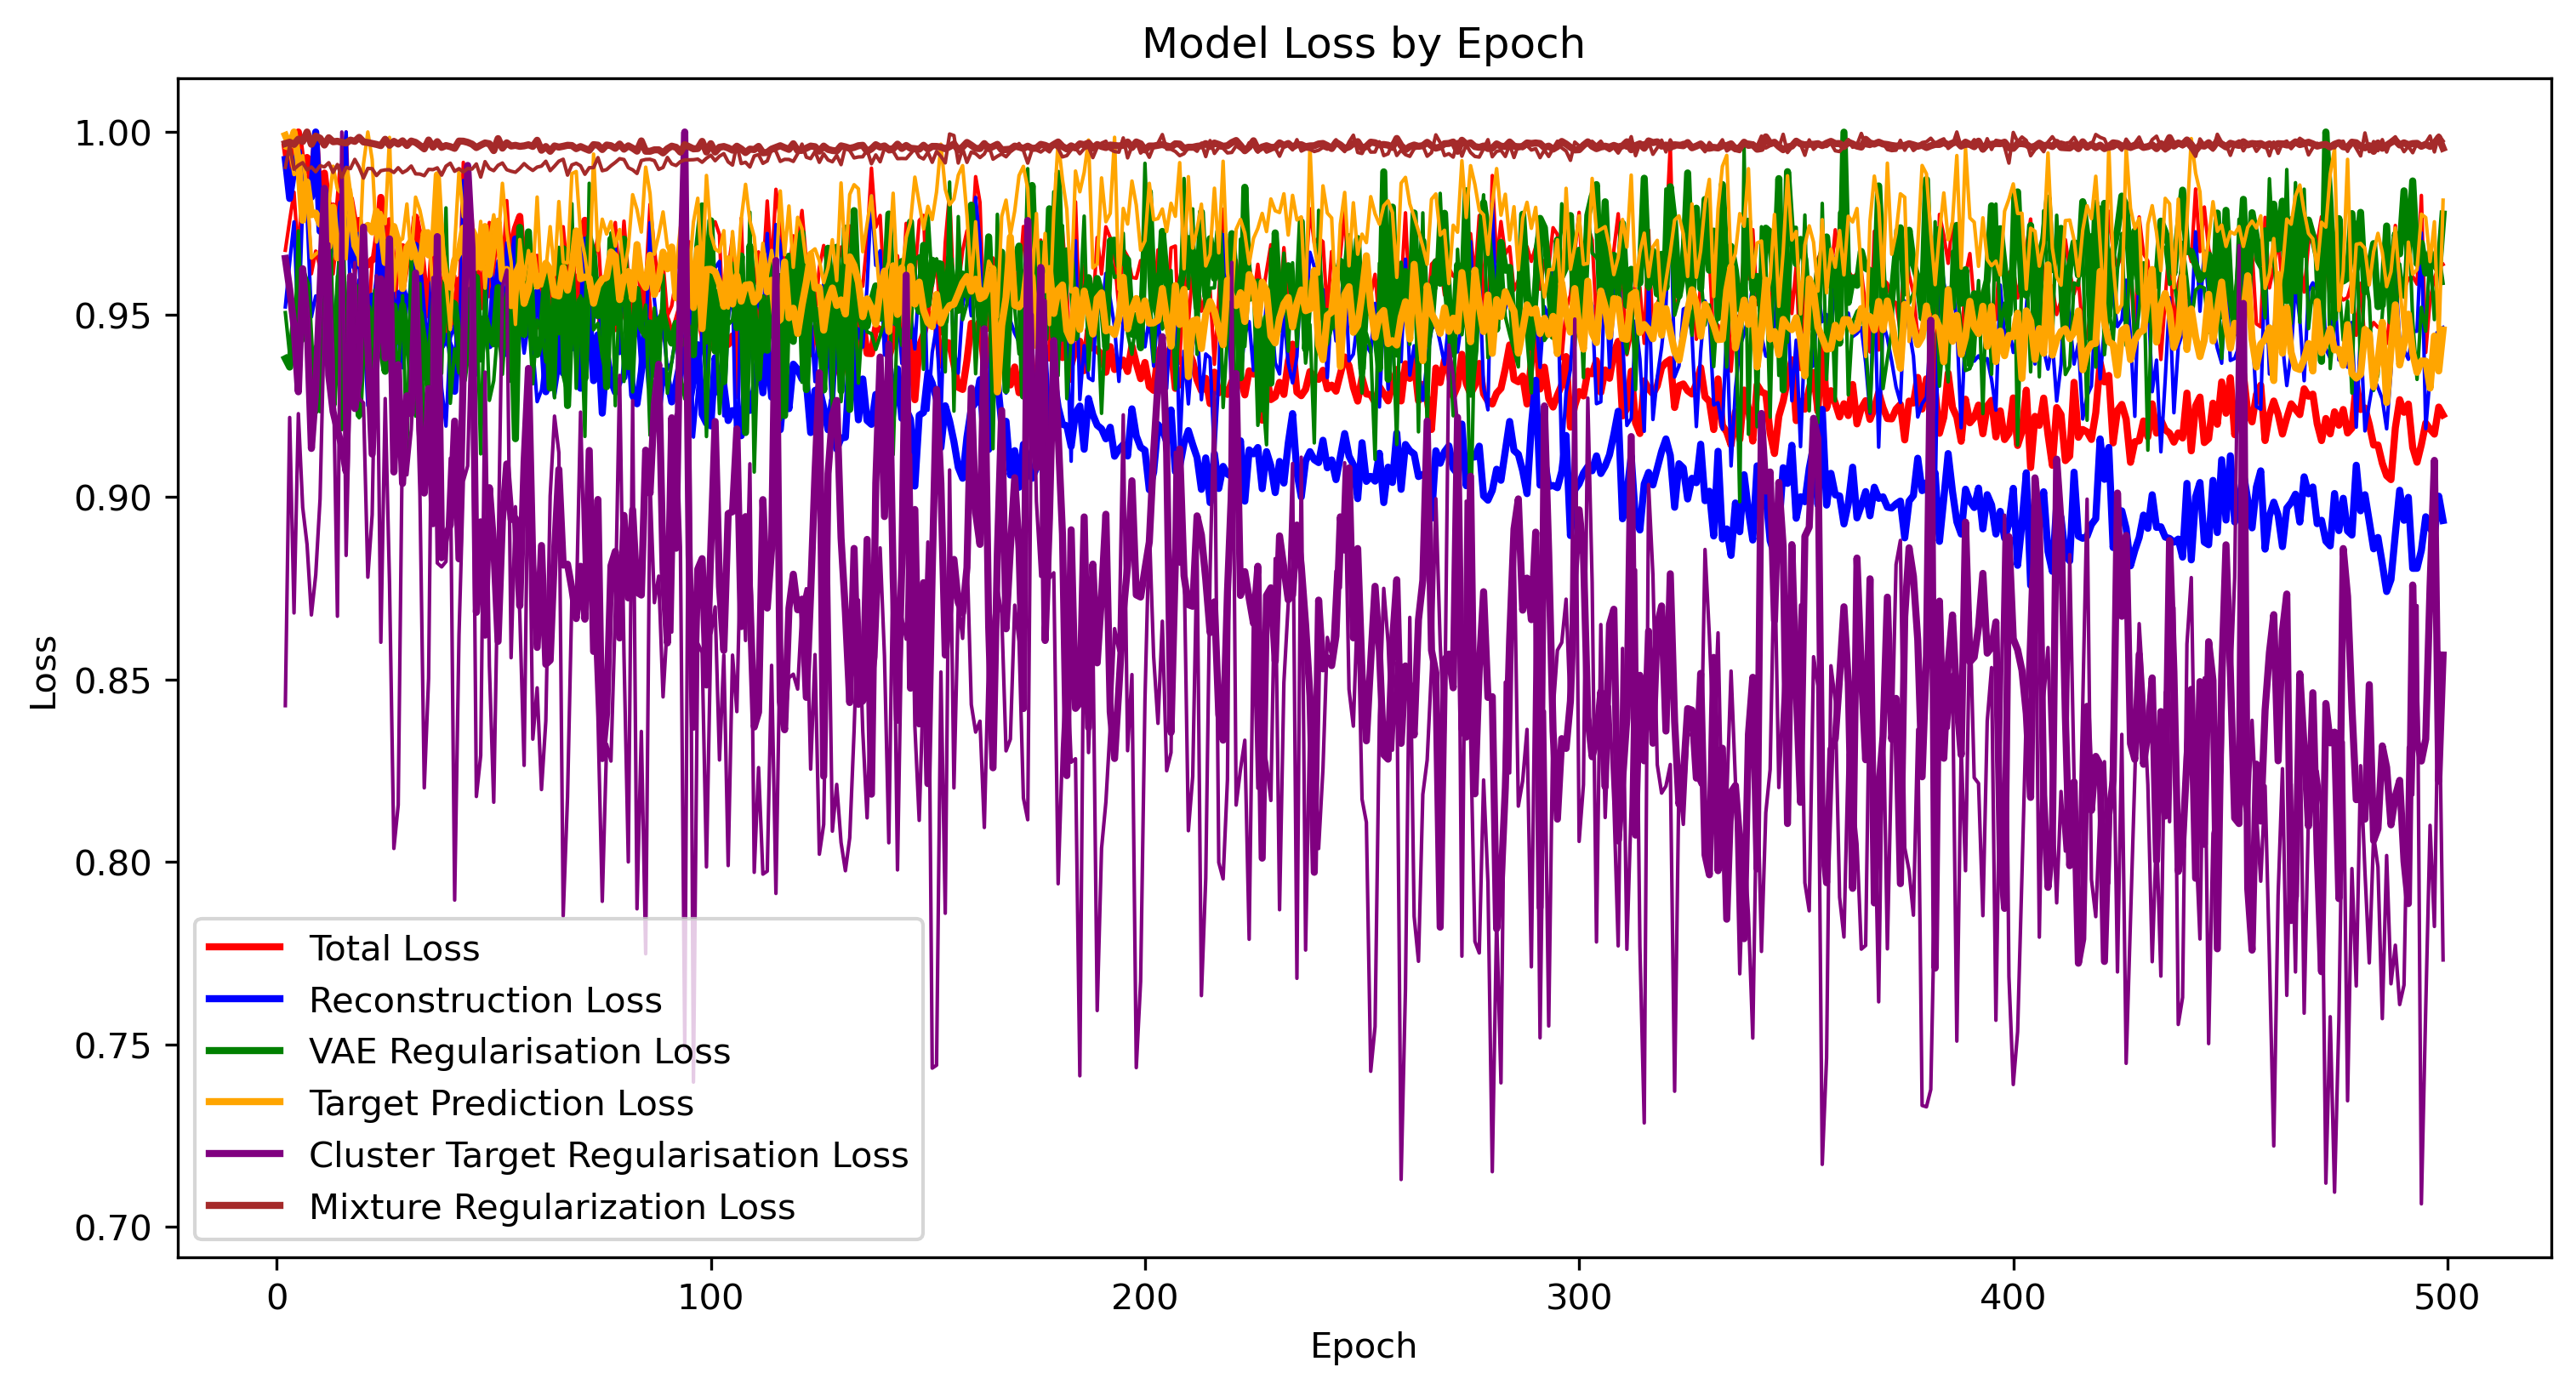

In [33]:
utils.plot_all_losses(history=history)